In [1]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # For CUDA determinism (optional but recommended)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True  # slower but repeatable
    torch.backends.cudnn.benchmark = False     # turn off auto-tuning

In [2]:
import numpy as np

data = np.load("GAF_BalancedDatasets.npz")

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

In [3]:
import matplotlib.pyplot as plt

def plot_gaf_sample_channels(X_data, y_data, sample_idx=0, cmap='viridis'):
    sample = X_data[sample_idx]  # shape: (7, 64, 64)
    label = y_data[sample_idx]

    fig, axs = plt.subplots(1, 7, figsize=(20, 3))
    for ch in range(7):
        axs[ch].imshow(sample[ch], cmap=cmap)
        axs[ch].axis('off')
        axs[ch].set_title(f"Channel {ch+1}")
    
    fig.suptitle(f"Sample #{sample_idx} - Label: {label}", fontsize=16)
    plt.tight_layout()
    plt.show()

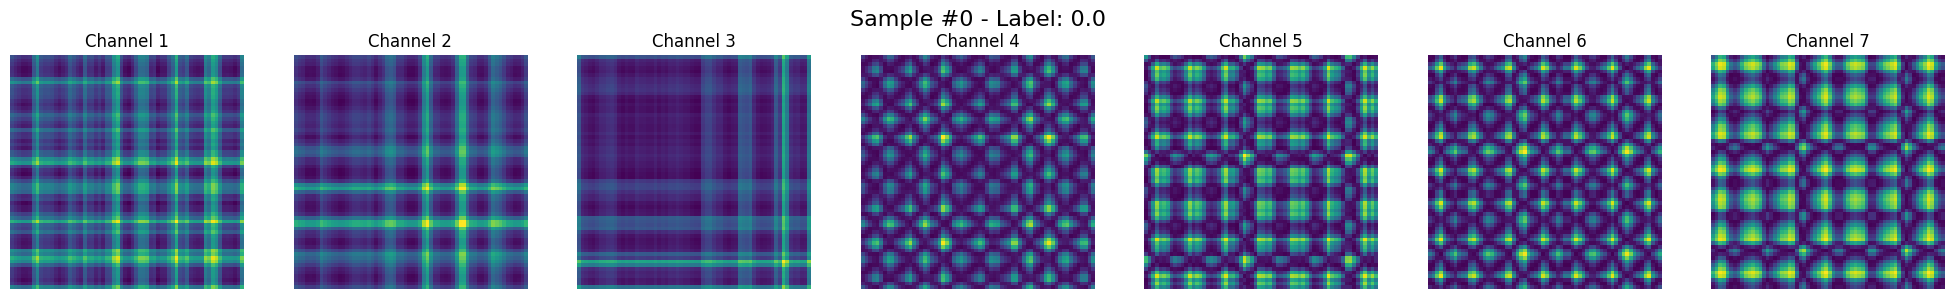

In [4]:
plot_gaf_sample_channels(X_train, y_train, sample_idx=0)

In [5]:
import torch
from torch.utils.data import Dataset

class GAFDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform  # optional: normalize or augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.y[idx]

In [6]:
set_seed(42)

In [7]:
from torch.utils.data import DataLoader

train_dataset = GAFDataset(X_train, y_train)
val_dataset   = GAFDataset(X_val, y_val)
test_dataset  = GAFDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os


# =========================================================
# 1. 基本设置
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

npz_path = "GAF_BalancedDatasets.npz"

batch_size = 32
num_epochs = 100
learning_rate = 1e-4
weight_decay = 1e-4
patience = 15

save_path = "best_gaf_cnn_vit_mlp_model.pth"


# =========================================================
# 2. 读取 npz 数据
# =========================================================

data = np.load(npz_path)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# =========================================================
# 3. 标签处理
# =========================================================
# 如果 y 是 one-hot，例如 shape = (N, num_classes)，转成类别编号
# 如果 y 已经是 (N,)，则不变

if len(y_train.shape) > 1:
    y_train = np.argmax(y_train, axis=1)
    y_val = np.argmax(y_val, axis=1)
    y_test = np.argmax(y_test, axis=1)

y_train = y_train.astype(np.int64)
y_val = y_val.astype(np.int64)
y_test = y_test.astype(np.int64)

num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)


# =========================================================
# 4. 数据集定义
# =========================================================

class GAFDataset(Dataset):
    def __init__(self, X, y):
        """
        支持以下几种输入格式：
        1. (N, 64, 64, 7)  -> NHWC
        2. (N, 7, 64, 64)  -> NCHW
        3. (N, 64, 7, 64)  -> NHCW
        """
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

        print("Original X shape in Dataset:", self.X.shape)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]

        # 情况 1: x = (64, 64, 7)
        # 转成 (7, 64, 64)
        if x.shape == (64, 64, 7):
            x = np.transpose(x, (2, 0, 1))

        # 情况 2: x = (7, 64, 64)
        # 已经是 PyTorch 格式，不需要改
        elif x.shape == (7, 64, 64):
            pass

        # 情况 3: x = (64, 7, 64)
        # 转成 (7, 64, 64)
        elif x.shape == (64, 7, 64):
            x = np.transpose(x, (1, 0, 2))

        else:
            raise ValueError(f"Unexpected input shape: {x.shape}")

        y = self.y[idx]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        return x, y


train_dataset = GAFDataset(X_train, y_train)
val_dataset = GAFDataset(X_val, y_val)
test_dataset = GAFDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


# =========================================================
# 5. CNN + ViT + MLP 模型
# =========================================================

class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=7, out_channels=128):
        super(CNNFeatureExtractor, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            # 64 x 64 -> 32 x 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            # 32 x 32 -> 16 x 16

            nn.Conv2d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
            # 输出: 128 x 16 x 16
        )

    def forward(self, x):
        return self.cnn(x)


class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=128, embed_dim=128, patch_size=4):
        super(PatchEmbedding, self).__init__()

        self.patch_size = patch_size

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        """
        x shape: (B, C, H, W)
        after projection: (B, embed_dim, H/patch, W/patch)
        flatten to: (B, num_patches, embed_dim)
        """
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


class GAF_CNN_ViT_MLP(nn.Module):
    def __init__(
        self,
        in_channels=7,
        num_classes=2,
        cnn_out_channels=128,
        embed_dim=128,
        patch_size=4,
        num_heads=4,
        num_transformer_layers=2,
        mlp_hidden_dim=128,
        dropout=0.3
    ):
        super(GAF_CNN_ViT_MLP, self).__init__()

        self.cnn = CNNFeatureExtractor(
            in_channels=in_channels,
            out_channels=cnn_out_channels
        )

        self.patch_embed = PatchEmbedding(
            in_channels=cnn_out_channels,
            embed_dim=embed_dim,
            patch_size=patch_size
        )

        # CNN 输出是 16 x 16
        # patch_size = 4 后，patch 数量为 4 x 4 = 16
        num_patches = (16 // patch_size) * (16 // patch_size)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    def forward(self, x):
        """
        input x: (B, 7, 64, 64)
        """
        x = self.cnn(x)
        x = self.patch_embed(x)

        batch_size = x.shape[0]

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embedding

        x = self.transformer(x)

        cls_output = x[:, 0]

        out = self.mlp_head(cls_output)

        return out


# =========================================================
# 6. 建立模型
# =========================================================

model = GAF_CNN_ViT_MLP(
    in_channels=7,
    num_classes=num_classes,
    cnn_out_channels=128,
    embed_dim=128,
    patch_size=4,
    num_heads=4,
    num_transformer_layers=2,
    mlp_hidden_dim=128,
    dropout=0.5
).to(device)

print(model)


# =========================================================
# 7. 损失函数和优化器
# =========================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)


# =========================================================
# 8. 训练与验证函数
# =========================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


# =========================================================
# 9. 正式训练
# =========================================================

best_val_loss = np.inf
early_stop_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch + 1:03d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "num_classes": num_classes,
                "history": history
            },
            save_path
        )

        print("Best model saved.")

    else:
        early_stop_counter += 1
        print(f"Early stopping counter: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break


# =========================================================
# 10. 测试集评估
# =========================================================

checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("\n================ Test Result ================")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


# =========================================================
# 11. 保存训练历史
# =========================================================

np.savez(
    "training_history_gaf_cnn_vit_mlp.npz",
    train_loss=np.array(history["train_loss"]),
    train_acc=np.array(history["train_acc"]),
    val_loss=np.array(history["val_loss"]),
    val_acc=np.array(history["val_acc"])
)

print("\nTraining history saved.")
print("Best model saved as:", save_path)

Using device: cuda
X_train shape: (7200, 7, 64, 64)
y_train shape: (7200,)
X_val shape: (1200, 7, 64, 64)
y_val shape: (1200,)
X_test shape: (1200, 7, 64, 64)
y_test shape: (1200,)
Number of classes: 3
Original X shape in Dataset: (7200, 7, 64, 64)
Original X shape in Dataset: (1200, 7, 64, 64)
Original X shape in Dataset: (1200, 7, 64, 64)
GAF_CNN_ViT_MLP(
  (cnn): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(7, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64

In [10]:
x=1

In [11]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

save_path = "best_gaf_cnn_vit_mlp_model.pth"

checkpoint = torch.load(save_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [12]:
all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(y_batch.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

print("Prediction finished.")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

Prediction finished.
y_true shape: (1200,)
y_pred shape: (1200,)
y_prob shape: (1200, 3)


In [13]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[373  15  12]
 [ 19 374   7]
 [ 86  73 241]]


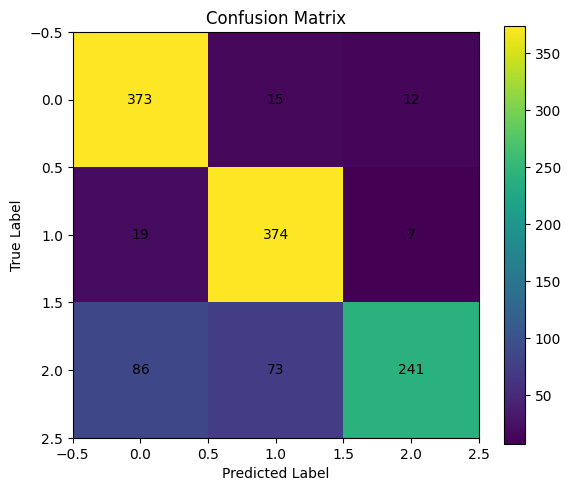

In [14]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()